## **Baselines Unimodales**

Una vez seleccionados los codificadores por cada modalidad que mayor rendimiento conjunto alcanzan en validación para el corpus global, que recordamos que son:

* **TEXTO**: **RoBERTa**
* **AUDIO**: **Wav2Vec 2.0**
* **VÍDEO**: **ResNet**

A continuación, fijando estos, se lleva a cabo un ajuste de hiperparámetros de los modelos independientes para el **corpus global** por cada codificador, y se evalúan en test para establecer una línea base de comparación de la mejora o no de rendimiento de la fusión de las arquitecturas multimodales posteriores. 

El notebook se estructura de la siguiente manera: 

1. **Ajuste de Hiperparámetros**: Tras esta selección, se ajustan los siguientes hiperparámetros **solo** en los modelos unimodales seleccionados tras la fusión temprana con el objetivo de obtener los baselines unimodales, para comparar posteriormente con la arquitectura multimodal ajustada y entrenada sobre el corpus global con estos mismos hiperparámetros también, y analizar así el impacto de la fusión:

    Para llevar a cabo el ajuste de hiperparámetros, se ha optado por realizar dos Grid Search secuenciales: 

    * **FASE 1: GRID SEARCH de Ventanas de contexto**. Partiendo de la configuración básica para el resto de hiperparámetros (la predeterminada), vamos a realizar una primera búsqueda en rejilla para todas las combinaciones posibles de ventanas de contexto de las modalidades: 

        * **Vídeo**: `32 frames` vs `16 frames`.
        * **Audio**: `11 segundos` vs `7 segundos`.
        * **Texto**: `64 tokens` vs `32 tokens`.

    De esta fase, fijamos **aquella ventana de contexto** con la que mayor F1-Score Macro alcanza el modelo unimodal. En este caso, no aplicamos un umbral de Recall, vistos los resultados en la métrica de Recall alcanzados en validación por los modelos unimodales. En todo caso, ante empate o valores muy ajustados en F1-Score Macro, se fija aquella configuración que obtenga el mayor **Recall** para la clase positiva (Estrés).

    * **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**. Con las ventanas ya óptimas fijadas, se ajustará el tamaño de la red y su nivel de regularización mediante otro grid search:

        * **Red grande**: `proj_dim = 512` y `hidden_mlp = 128` vs **Red pequeña**:  `proj_dim = 256` y `hidden_mp = 64`.
        * **Dropout**: `0.5`(estándar) vs `0.3`(menor regularización, permite mayor flujo de información). 
        * **Learning Rate (`lr`)**: `1e-4` vs `5e-5` vs `1e-5`. Probamos con valores bajos ya que nuestro dataset es pequeño y desbalanceado, no conviene dar pasos grandes.

    Los valores indicados para el ajuste por cada hiperparámetro se han extraído de la literatura (excepto las ventanas, extraídas del EDA). Se han limitado a una cantidad razonable para evitar la explosión combinatoria. Estos mismos hiperparámetros se ajustarán, empleando el mismo proceso de **dos Grid Search** secuenciales, para las arquitecturas multimodales.

2. **Resultados de Evaluación en Test**: Se analizan los resultados para test, ya que estos se compararán con los resultados en test de las posteriores arquitecturas de fusión ajustadas sobre el corpus global. 

In [8]:
# Importación de las librerías
import os
import torch
import pandas as pd
import subprocess
import json
from IPython.display import display, Image

# Configuración del dispositivo:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entorno de ejecución configurado en: {device}")

Entorno de ejecución configurado en: cuda


## **1. Ajuste de Hiperparámetros**

En el notebook `9_Seleccion_Extractor_Caracteristicas`, tras aplicar fusión temprana, se han seleccionado aquellos modelos preentrenados que mayor rendimiento conjunto logran para la tarea en validación fijando hiperparámetros estándar, y son los siguientes:
* **RoBERTa**, **Wav2Vec 2.0** y **ResNet**.

Estos se fijan para los baselines unimodales, bimodales y modelos multimodales a construir a continuación. 

### **Baselines Unimodales**

* **ResNet**:
    * **FASE 1: GRID SEARCH de Ventanas de contexto**:

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]


mejor_f1 = 0.0
mejor_config = None
mejor_historial = None
for video_frames in VENTANAS_VIDEO:

    comando = (
            f"python train.py "
            f"--video resnet "
            f"--video_frames {video_frames} "
    )

    _ = subprocess.run(comando, shell=True)

    archivo_json = f"historial_pesos_baseline_unimodal_video_resnet_ventana{video_frames}_pdim512_hmlp128_do0.5_lr0.0001.json"

    if os.path.exists(archivo_json):
        with open(archivo_json, "r") as f:
            historial = json.load(f)
        # Buscamos el índice de la época con el mejor F1
        mejores_f1_lista = historial['val_f1']
        if mejores_f1_lista:
            mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
            val_f1 = historial['val_f1'][mejor_indice]
            val_recall = historial['val_recall_estres'][mejor_indice]

    print(f"\n RESNET --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")            

    mejora_f1 = val_f1 > mejor_f1

    model_path = f"pesos_baseline_unimodal_video_resnet_ventana{video_frames}_pdim512_hmlp128_do0.5_lr0.0001.pth"

    if mejora_f1 :
        # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
        if mejor_config is not None and mejor_historial is not None:
            for archivo in [mejor_config, mejor_historial]:
                if os.path.exists(archivo):
                    os.remove(archivo)

        mejor_f1 = val_f1
        mejor_config = model_path
        mejor_historial = archivo_json
        print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {mejor_config}")
    else :
        for archivo in [model_path, archivo_json]:
            if os.path.exists(archivo):
                os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

ENTRENAMIENTO BASELINE:
Modalidad: VIDEO
Backbone: RESNET


Epoch 1/20: 100%|██████████| 453/453 [00:07<00:00, 63.91it/s, loss=0.93] 


Epoch 1. Train Loss: 0.9872. Val Loss: 1.1063. Val F1 Macro: 0.5438. Val Recall Estrés: 0.7119

Nuevo mejor modelo: (F1: 0.5438) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:05<00:00, 77.35it/s, loss=0.766]


Epoch 2. Train Loss: 0.9625. Val Loss: 1.1109. Val F1 Macro: 0.5440. Val Recall Estrés: 0.6953

Nuevo mejor modelo: (F1: 0.5440) -> Guardando pesos...


...

Epoch 8. Train Loss: 0.8137. Val Loss: 1.2760. Val F1 Macro: 0.5354. Val Recall Estrés: 0.5370

Sin mejora en F1-Score. Límite: 3/5


Epoch 9/20: 100%|██████████| 453/453 [00:05<00:00, 76.53it/s, loss=1.03] 


Epoch 9. Train Loss: 0.7891. Val Loss: 1.2861. Val F1 Macro: 0.5340. Val Recall Estrés: 0.5279

Sin mejora en F1-Score. Límite: 4/5


Epoch 10/20: 100%|██████████| 453/453 [00:05<00:00, 76.06it/s, loss=0.718]


Epoch 10. Train Loss: 0.7593. Val Loss: 1.3088. Val F1 Macro: 0.5326. Val Recall Estrés: 0.4751

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 10 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_baseline_unimodal_video_resnet_ventana16_pdim512_hmlp128_do0.5_lr0.0001.pth
Historial de entrenamiento guardado en: ./historial_pesos_baseline_unimodal_video_resnet_ventana16_pdim512_hmlp128_do0.5_lr0.0001.json

 RESNET --> F1: 0.5645 | Recall estrés: 0.5988

CONFIGURACIÓN GANADORA: pesos_baseline_unimodal_video_resnet_ventana32_pdim512_hmlp128_do0.5_lr0.0001.pth
Mejor Val F1: 0.5657


La ventana óptima obtenida es de **32 frames**.  

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

video_frames = 32
mejor_f1 = 0.0
mejor_config = None
mejor_historial = None
for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            comando = (
                    f"python train.py "
                    f"--video resnet "
                    f"--video_frames {video_frames} "
                    f"--proj_dim {prj_dim} "
                    f"--hidden_mlp {h_mlp} "
                    f"--lr {lr} "
                    f"--dropout {do} "
            )

            _ = subprocess.run(comando, shell=True)

            archivo_json = f"historial_pesos_baseline_unimodal_video_resnet_ventana{video_frames}_pdim{prj_dim}_hmlp{h_mlp}_do{do}_lr{lr}.json"

            if os.path.exists(archivo_json):
                with open(archivo_json, "r") as f:
                    historial = json.load(f)
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]
        
            print(f"\n RESNET --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")            
        
            mejora_f1 = val_f1 > mejor_f1
        
            model_path = f"pesos_baseline_unimodal_video_resnet_ventana{video_frames}_pdim{prj_dim}_hmlp{h_mlp}_do{do}_lr{lr}.pth"
        
            if mejora_f1 :
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None and mejor_historial is not None:
                    for archivo in [mejor_config, mejor_historial]:
                        if os.path.exists(archivo):
                            os.remove(archivo)
        
                mejor_f1 = val_f1
                mejor_config = model_path
                mejor_historial = archivo_json
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {mejor_config}")
            else :
                for archivo in [model_path, archivo_json]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

ENTRENAMIENTO BASELINE:
Modalidad: VIDEO
Backbone: RESNET


Epoch 1/20: 100%|██████████| 453/453 [00:06<00:00, 69.79it/s, loss=1.07] 


Epoch 1. Train Loss: 0.9887. Val Loss: 1.1251. Val F1 Macro: 0.5424. Val Recall Estrés: 0.7195

Nuevo mejor modelo: (F1: 0.5424) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:06<00:00, 71.47it/s, loss=0.96] 


Epoch 2. Train Loss: 0.9623. Val Loss: 1.1292. Val F1 Macro: 0.5611. Val Recall Estrés: 0.6833

Nuevo mejor modelo: (F1: 0.5611) -> Guardando pesos...


...

Epoch 7. Train Loss: 0.8517. Val Loss: 1.1375. Val F1 Macro: 0.5657. Val Recall Estrés: 0.5867

Sin mejora en F1-Score. Límite: 3/5


Epoch 8/20: 100%|██████████| 453/453 [00:06<00:00, 73.55it/s, loss=0.525]


Epoch 8. Train Loss: 0.8360. Val Loss: 1.1841. Val F1 Macro: 0.5187. Val Recall Estrés: 0.3575

Sin mejora en F1-Score. Límite: 4/5


Epoch 9/20: 100%|██████████| 453/453 [00:06<00:00, 71.82it/s, loss=0.713]


Epoch 9. Train Loss: 0.8210. Val Loss: 1.1948. Val F1 Macro: 0.5475. Val Recall Estrés: 0.4811

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 9 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_baseline_unimodal_video_resnet_ventana32_pdim256_hmlp64_do0.3_lr1e-05.pth
Historial de entrenamiento guardado en: ./historial_pesos_baseline_unimodal_video_resnet_ventana32_pdim256_hmlp64_do0.3_lr1e-05.json

 RESNET --> F1: 0.5743 | Recall estrés: 0.6320
--> NUEVO MEJOR MODELO (F1=0.5743 | Recall=0.6320): pesos_baseline_unimodal_video_resnet_ventana32_pdim256_hmlp64_do0.3_lr1e-05.pth

CONFIGURACIÓN GANADORA: pesos_baseline_unimodal_video_resnet_ventana32_pdim256_hmlp64_do0.3_lr1e-05.pth
Mejor Val F1: 0.5743


Tras el ajuste de hiperparámetros, tenemos la siguiente configuración óptima:
* **ResNet (F1=0.5743 | Recall=0.6320)**:
    * **Ventana**: 32 frames
    * **Arquitectura**:
        * Red pequeña: `proj_dim` = 256, `hidden_mlp` = 64
        * **Dropout**: 0.3
        * **Learning Rate**: 1e-05



* **Wav2Vec 2.0**:
    * **FASE 1: GRID SEARCH de Ventanas de contexto**:

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_AUDIO = [11, 7]


mejor_f1 = 0.0
mejor_config = None
mejor_historial = None
for audio_len in VENTANAS_AUDIO:

    comando = (
            f"python train.py "
            f"--audio wav2vec "
            f"--audio_len {audio_len} "
    )

    _ = subprocess.run(comando, shell=True)

    archivo_json = f"historial_pesos_baseline_unimodal_audio_wav2vec_ventana{audio_len}_pdim512_hmlp128_do0.5_lr0.0001.json"

    if os.path.exists(archivo_json):
        with open(archivo_json, "r") as f:
            historial = json.load(f)
        # Buscamos el índice de la época con el mejor F1
        mejores_f1_lista = historial['val_f1']
        if mejores_f1_lista:
            mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
            val_f1 = historial['val_f1'][mejor_indice]
            val_recall = historial['val_recall_estres'][mejor_indice]

    print(f"\n WAV2VEC --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")            

    mejora_f1 = val_f1 > mejor_f1

    model_path = f"pesos_baseline_unimodal_audio_wav2vec_ventana{audio_len}_pdim512_hmlp128_do0.5_lr0.0001.pth"

    if mejora_f1 :
        # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
        if mejor_config is not None and mejor_historial is not None:
            for archivo in [mejor_config, mejor_historial]:
                if os.path.exists(archivo):
                    os.remove(archivo)

        mejor_f1 = val_f1
        mejor_config = model_path
        mejor_historial = archivo_json
        print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {mejor_config}")
    else :
        for archivo in [model_path, archivo_json]:
            if os.path.exists(archivo):
                os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

ENTRENAMIENTO BASELINE:
Modalidad: AUDIO
Backbone: WAV2VEC


Epoch 1/20: 100%|██████████| 453/453 [00:31<00:00, 14.49it/s, loss=1.03] 


Epoch 1. Train Loss: 1.1122. Val Loss: 1.1327. Val F1 Macro: 0.2371. Val Recall Estrés: 0.9894

Nuevo mejor modelo: (F1: 0.2371) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:30<00:00, 14.92it/s, loss=1.2]  


Epoch 2. Train Loss: 1.0990. Val Loss: 1.1364. Val F1 Macro: 0.2301. Val Recall Estrés: 0.9940

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 13. Train Loss: 1.0484. Val Loss: 1.1015. Val F1 Macro: 0.3096. Val Recall Estrés: 0.9729

Sin mejora en F1-Score. Límite: 3/5


Epoch 14/20: 100%|██████████| 453/453 [00:17<00:00, 25.96it/s, loss=1.22] 


Epoch 14. Train Loss: 1.0525. Val Loss: 1.1149. Val F1 Macro: 0.3089. Val Recall Estrés: 0.9367

Sin mejora en F1-Score. Límite: 4/5


Epoch 15/20: 100%|██████████| 453/453 [00:17<00:00, 26.62it/s, loss=0.836]


Epoch 15. Train Loss: 1.0423. Val Loss: 1.1435. Val F1 Macro: 0.2813. Val Recall Estrés: 0.9623

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 15 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_baseline_unimodal_audio_wav2vec_ventana7_pdim512_hmlp128_do0.5_lr0.0001.pth
Historial de entrenamiento guardado en: ./historial_pesos_baseline_unimodal_audio_wav2vec_ventana7_pdim512_hmlp128_do0.5_lr0.0001.json

 WAV2VEC --> F1: 0.5318 | Recall estrés: 0.1825
--> NUEVO MEJOR MODELO (F1=0.5318 | Recall=0.1825): pesos_baseline_unimodal_audio_wav2vec_ventana7_pdim512_hmlp128_do0.5_lr0.0001.pth

CONFIGURACIÓN GANADORA: pesos_baseline_unimodal_audio_wav2vec_ventana7_pdim512_hmlp128_do0.5_lr0.0001.pth
Mejor Val F1: 0.5318


La ventana óptima es de **7 segundos**.

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

audio_len = 7
mejor_f1 = 0.0
mejor_config = None
mejor_historial = None
   
for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            comando = (
                    f"python train.py "
                    f"--audio wav2vec "
                    f"--audio_len {audio_len} "
                    f"--proj_dim {prj_dim} "
                    f"--hidden_mlp {h_mlp} "
                    f"--lr {lr} "
                    f"--dropout {do} "
            )

            _ = subprocess.run(comando, shell=True)

            archivo_json = f"historial_pesos_baseline_unimodal_audio_wav2vec_ventana{audio_len}_pdim{prj_dim}_hmlp{h_mlp}_do{do}_lr{lr}.json"

            if os.path.exists(archivo_json):
                with open(archivo_json, "r") as f:
                    historial = json.load(f)
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]
        
            print(f"\n WAV2VEC --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")            
        
            mejora_f1 = val_f1 > mejor_f1
        
            model_path = f"pesos_baseline_unimodal_audio_wav2vec_ventana{audio_len}_pdim{prj_dim}_hmlp{h_mlp}_do{do}_lr{lr}.pth"
        
            if mejora_f1 :
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None and mejor_historial is not None:
                    for archivo in [mejor_config, mejor_historial]:
                        if os.path.exists(archivo):
                            os.remove(archivo)
        
                mejor_f1 = val_f1
                mejor_config = model_path
                mejor_historial = archivo_json
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {mejor_config}")
            else :
                for archivo in [model_path, archivo_json]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

ENTRENAMIENTO BASELINE:
Modalidad: AUDIO
Backbone: WAV2VEC


Epoch 1/20: 100%|██████████| 453/453 [00:18<00:00, 25.15it/s, loss=1.32] 


Epoch 1. Train Loss: 1.0935. Val Loss: 1.1318. Val F1 Macro: 0.5118. Val Recall Estrés: 0.1448

Nuevo mejor modelo: (F1: 0.5118) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:16<00:00, 27.21it/s, loss=0.967]


Epoch 2. Train Loss: 1.0820. Val Loss: 1.1383. Val F1 Macro: 0.5090. Val Recall Estrés: 0.1478

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 11. Train Loss: 1.0664. Val Loss: 1.1293. Val F1 Macro: 0.2477. Val Recall Estrés: 0.9774

Sin mejora en F1-Score. Límite: 3/5


Epoch 12/20: 100%|██████████| 453/453 [00:17<00:00, 26.52it/s, loss=1.2]  


Epoch 12. Train Loss: 1.0674. Val Loss: 1.1269. Val F1 Macro: 0.2532. Val Recall Estrés: 0.9729

Sin mejora en F1-Score. Límite: 4/5


Epoch 13/20: 100%|██████████| 453/453 [00:20<00:00, 22.62it/s, loss=1]    


Epoch 13. Train Loss: 1.0650. Val Loss: 1.1320. Val F1 Macro: 0.2506. Val Recall Estrés: 0.9713

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 13 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_baseline_unimodal_audio_wav2vec_ventana7_pdim256_hmlp64_do0.3_lr1e-05.pth
Historial de entrenamiento guardado en: ./historial_pesos_baseline_unimodal_audio_wav2vec_ventana7_pdim256_hmlp64_do0.3_lr1e-05.json

 WAV2VEC --> F1: 0.2555 | Recall estrés: 0.9668

CONFIGURACIÓN GANADORA: pesos_baseline_unimodal_audio_wav2vec_ventana7_pdim512_hmlp128_do0.3_lr0.0001.pth
Mejor Val F1: 0.5342


Tras el ajuste de hiperparámetros, tenemos la siguiente configuración óptima:
* **Wav2Vec 2.0 (F1=0.5342 | Recall=0.1735)**:
    * **Ventana**: 7 segundos
    * **Arquitectura**:
        * Red pequeña: `proj_dim` = 512, `hidden_mlp` = 128
        * **Dropout**: 0.3
        * **Learning Rate**: 0.0001

* **RoBERTa**:
    * **FASE 1: GRID SEARCH de Ventanas de contexto**:

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_TEXTO = [64, 32]

mejor_f1 = 0.0
mejor_config = None
mejor_historial = None
for texto_tokens in VENTANAS_TEXTO:

    comando = (
            f"python train.py "
            f"--text roberta{texto_tokens} "
    )

    _ = subprocess.run(comando, shell=True)


    archivo_json = f"historial_pesos_baseline_unimodal_texto_roberta{texto_tokens}_ventana{texto_tokens}_pdim512_hmlp128_do0.5_lr0.0001.json"

    if os.path.exists(archivo_json):
        with open(archivo_json, "r") as f:
            historial = json.load(f)
        # Buscamos el índice de la época con el mejor F1
        mejores_f1_lista = historial['val_f1']
        if mejores_f1_lista:
            mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
            val_f1 = historial['val_f1'][mejor_indice]
            val_recall = historial['val_recall_estres'][mejor_indice]

    print(f"\n ROBERTA --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")            

    mejora_f1 = val_f1 > mejor_f1

    model_path = f"pesos_baseline_unimodal_texto_roberta{texto_tokens}_ventana{texto_tokens}_pdim512_hmlp128_do0.5_lr0.0001.pth"

    if mejora_f1 :
        # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
        if mejor_config is not None and mejor_historial is not None:
            for archivo in [mejor_config, mejor_historial]:
                if os.path.exists(archivo):
                    os.remove(archivo)

        mejor_f1 = val_f1
        mejor_config = model_path
        mejor_historial = archivo_json
        print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {mejor_config}")
    else :
        for archivo in [model_path, archivo_json]:
            if os.path.exists(archivo):
                os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

ENTRENAMIENTO BASELINE:
Modalidad: TEXTO
Backbone: ROBERTA64


Epoch 1/20: 100%|██████████| 453/453 [00:03<00:00, 140.73it/s, loss=0.843]


Epoch 1. Train Loss: 0.9893. Val Loss: 0.9428. Val F1 Macro: 0.6648. Val Recall Estrés: 0.7210

Nuevo mejor modelo: (F1: 0.6648) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:02<00:00, 154.75it/s, loss=0.837]


Epoch 2. Train Loss: 0.9166. Val Loss: 0.9237. Val F1 Macro: 0.6924. Val Recall Estrés: 0.6998

Nuevo mejor modelo: (F1: 0.6924) -> Guardando pesos...


...

Epoch 9. Train Loss: 0.8219. Val Loss: 0.8569. Val F1 Macro: 0.6690. Val Recall Estrés: 0.8220

Sin mejora en F1-Score. Límite: 3/5


Epoch 11/20:   4%|▎         | 16/453 [00:00<00:02, 152.22it/s, loss=0.88] 

Epoch 10. Train Loss: 0.7972. Val Loss: 0.8486. Val F1 Macro: 0.6868. Val Recall Estrés: 0.7526

Sin mejora en F1-Score. Límite: 4/5


Epoch 11/20: 100%|██████████| 453/453 [00:02<00:00, 163.37it/s, loss=0.733]


Epoch 11. Train Loss: 0.7954. Val Loss: 0.8472. Val F1 Macro: 0.6687. Val Recall Estrés: 0.8190

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 11 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_baseline_unimodal_texto_roberta32_ventana32_pdim512_hmlp128_do0.5_lr0.0001.pth
Historial de entrenamiento guardado en: ./historial_pesos_baseline_unimodal_texto_roberta32_ventana32_pdim512_hmlp128_do0.5_lr0.0001.json

 ROBERTA --> F1: 0.7099 | Recall estrés: 0.6440

CONFIGURACIÓN GANADORA: pesos_baseline_unimodal_texto_roberta64_ventana64_pdim512_hmlp128_do0.5_lr0.0001.pth
Mejor Val F1: 0.7350


La ventana óptima es de **64 tokens**. 

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------
confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

texto_tokens = 64
mejor_f1 = 0.0
mejor_config = None
mejor_historial = None
   
for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            comando = (
                    f"python train.py "
                    f"--text roberta{texto_tokens} "
                    f"--proj_dim {prj_dim} "
                    f"--hidden_mlp {h_mlp} "
                    f"--lr {lr} "
                    f"--dropout {do} "
            )

            _ = subprocess.run(comando, shell=True)

            archivo_json = f"historial_pesos_baseline_unimodal_texto_roberta{texto_tokens}_ventana{texto_tokens}_pdim{prj_dim}_hmlp{h_mlp}_do{do}_lr{lr}.json"

            if os.path.exists(archivo_json):
                with open(archivo_json, "r") as f:
                    historial = json.load(f)
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]
        
            print(f"\n ROBERTA --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")            
        
            mejora_f1 = val_f1 > mejor_f1
        
            model_path = f"pesos_baseline_unimodal_texto_roberta{texto_tokens}_ventana{texto_tokens}_pdim{prj_dim}_hmlp{h_mlp}_do{do}_lr{lr}.pth"
        
            if mejora_f1 :
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None and mejor_historial is not None:
                    for archivo in [mejor_config, mejor_historial]:
                        if os.path.exists(archivo):
                            os.remove(archivo)
        
                mejor_f1 = val_f1
                mejor_config = model_path
                mejor_historial = archivo_json
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {mejor_config}")
            else :
                for archivo in [model_path, archivo_json]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

ENTRENAMIENTO BASELINE:
Modalidad: TEXTO
Backbone: ROBERTA64


Epoch 1/20: 100%|██████████| 453/453 [00:03<00:00, 147.03it/s, loss=1.06] 


Epoch 1. Train Loss: 0.9903. Val Loss: 0.9404. Val F1 Macro: 0.6639. Val Recall Estrés: 0.7255

Nuevo mejor modelo: (F1: 0.6639) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:02<00:00, 166.64it/s, loss=0.866]


Epoch 2. Train Loss: 0.9157. Val Loss: 0.9067. Val F1 Macro: 0.6745. Val Recall Estrés: 0.7195

Nuevo mejor modelo: (F1: 0.6745) -> Guardando pesos...


...

Epoch 14. Train Loss: 0.8653. Val Loss: 0.8948. Val F1 Macro: 0.6692. Val Recall Estrés: 0.7647

Sin mejora en F1-Score. Límite: 3/5


Epoch 15/20: 100%|██████████| 453/453 [00:02<00:00, 155.08it/s, loss=0.856]


Epoch 15. Train Loss: 0.8598. Val Loss: 0.8904. Val F1 Macro: 0.6728. Val Recall Estrés: 0.7617

Sin mejora en F1-Score. Límite: 4/5


Epoch 16/20: 100%|██████████| 453/453 [00:03<00:00, 149.73it/s, loss=0.567]


Epoch 16. Train Loss: 0.8543. Val Loss: 0.8890. Val F1 Macro: 0.6775. Val Recall Estrés: 0.7526

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 16 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_baseline_unimodal_texto_roberta64_ventana64_pdim256_hmlp64_do0.3_lr1e-05.pth
Historial de entrenamiento guardado en: ./historial_pesos_baseline_unimodal_texto_roberta64_ventana64_pdim256_hmlp64_do0.3_lr1e-05.json

 ROBERTA --> F1: 0.6778 | Recall estrés: 0.7285

CONFIGURACIÓN GANADORA: pesos_baseline_unimodal_texto_roberta64_ventana64_pdim512_hmlp128_do0.3_lr5e-05.pth
Mejor Val F1: 0.7468


Tras el ajuste de hiperparámetros, tenemos la siguiente configuración óptima:
* **RoBERTa (F1=0.7468 | Recall=0.6893)**:
    * **Ventana**: 64 tokens
    * **Arquitectura**:
        * Red pequeña: `proj_dim` = 512, `hidden_mlp` = 128
        * **Dropout**: 0.3
        * **Learning Rate**: 5e-05

## **2. Evaluación en Test**

* **ResNet**:

100%|██████████| 4257/4257 [00:05<00:00, 747.06it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 5,396,481
Parámetros Entrenables: 5,396,481
Tiempo medio de Inferencia: 0.69 ms / muestra
ROC-AUC Score: 0.6553
F1 Macro: 0.5847
F1 Weighted: 0.6797
Accuracy (en %): 65.63%
Balanced Accuracy (en %): 61.38%


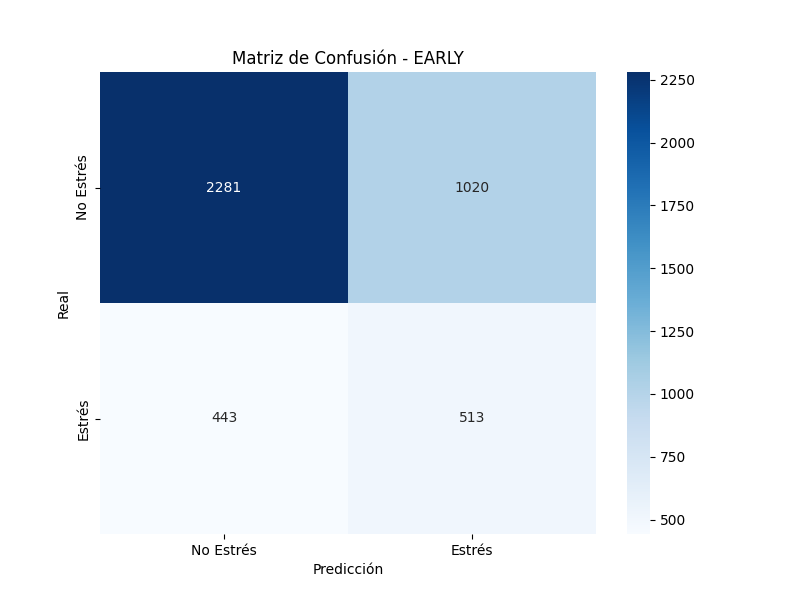

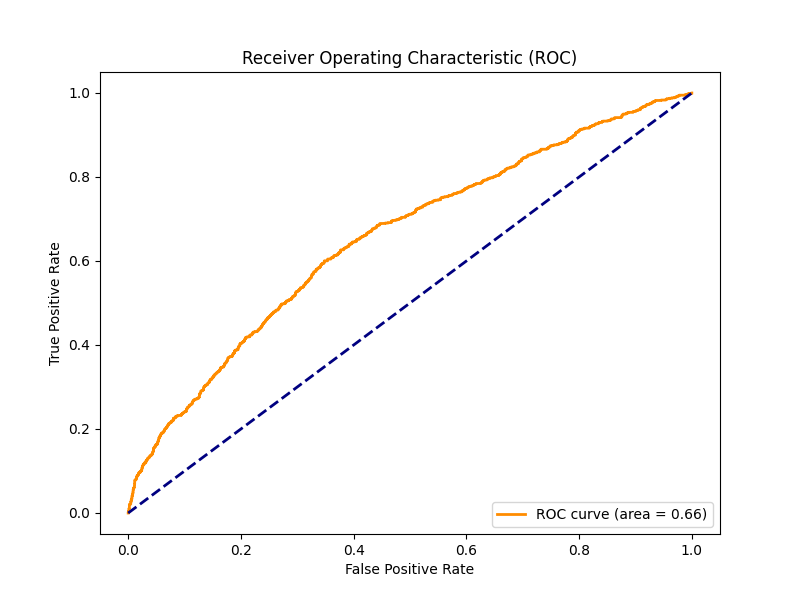

In [9]:
path_pesos = "pesos/unimodales_ajuste/pesos_baseline_unimodal_video_resnet_ventana32_pdim256_hmlp64_do0.3_lr1e-05.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--split test "
        f"--video resnet "
        f"--video_frames 32 "
        f"--proj_dim 256 "
        f"--hidden_mlp 64 "
        f"--dropout 0.3 "
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_VIDEO_resnet_test.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_VIDEO_resnet_test.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))


* **Wav2Vec 2.0**:

100%|██████████| 4257/4257 [00:15<00:00, 267.69it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 2,956,289
Parámetros Entrenables: 2,956,289
Tiempo medio de Inferencia: 2.86 ms / muestra
ROC-AUC Score: 0.5797
F1 Macro: 0.5330
F1 Weighted: 0.7112
Accuracy (en %): 75.71%
Balanced Accuracy (en %): 53.91%


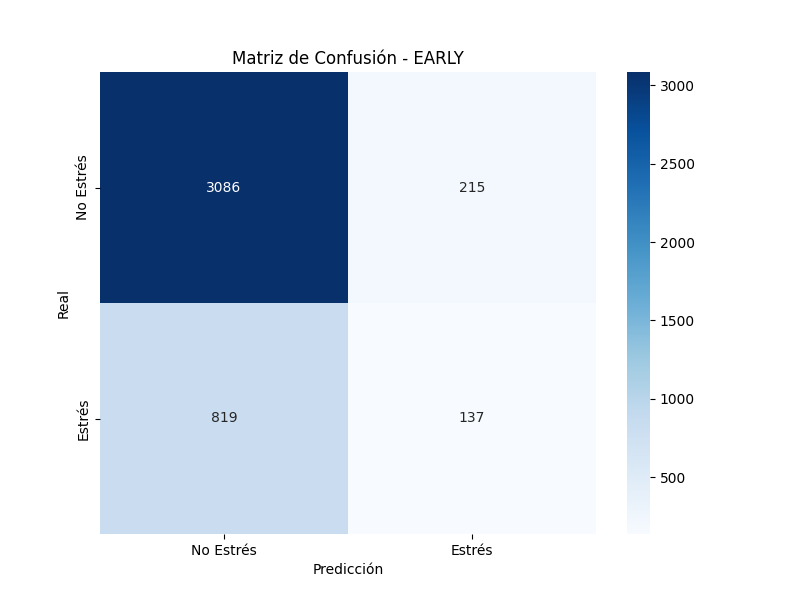

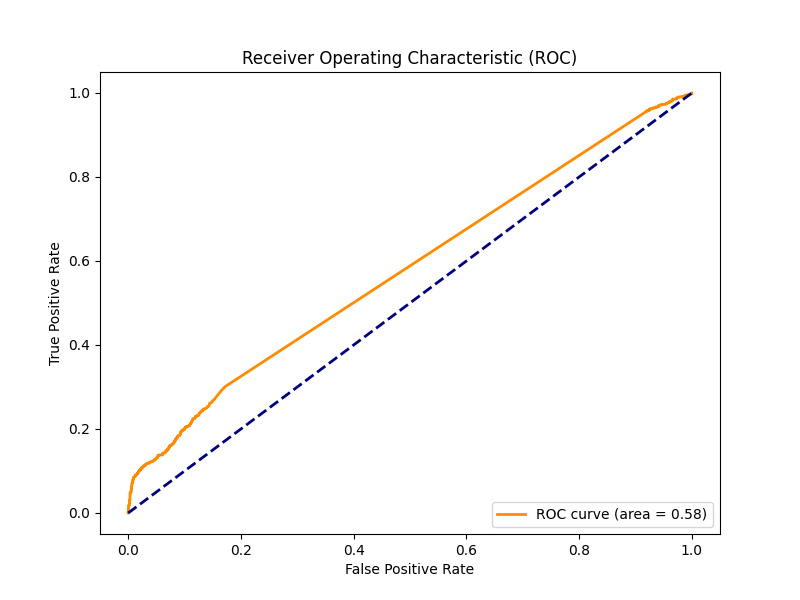

In [10]:
path_pesos = "pesos/unimodales_ajuste/pesos_baseline_unimodal_audio_wav2vec_ventana7_pdim512_hmlp128_do0.3_lr0.0001.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--split test "
        f"--audio wav2vec "
        f"--audio_len 7 "
        f"--proj_dim 512 "
        f"--hidden_mlp 128 "
        f"--dropout 0.3 "
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_AUDIO_wav2vec_test.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_AUDIO_wav2vec_test.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* **RoBERTa**:

100%|██████████| 4257/4257 [00:02<00:00, 1751.41it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 460,801
Parámetros Entrenables: 460,801
Tiempo medio de Inferencia: 0.18 ms / muestra
ROC-AUC Score: 0.8078
F1 Macro: 0.7137
F1 Weighted: 0.7942
Accuracy (en %): 78.83%
Balanced Accuracy (en %): 72.79%


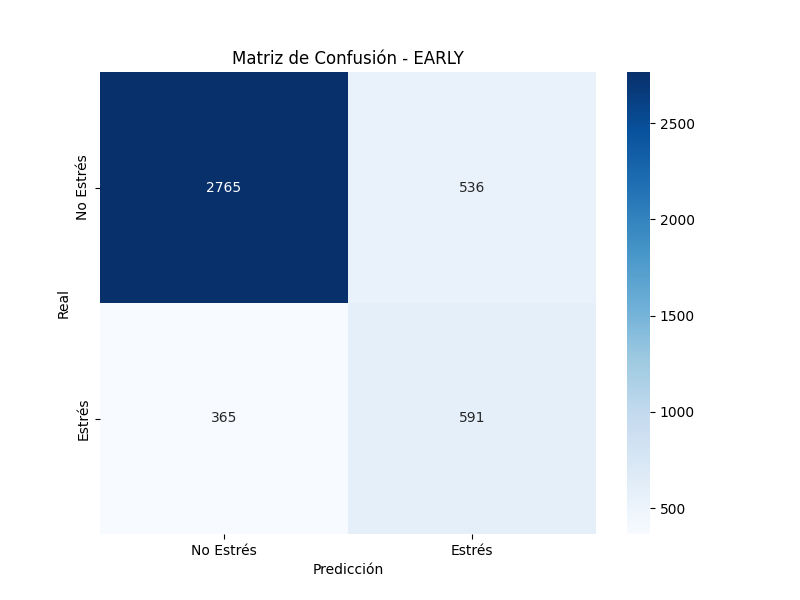

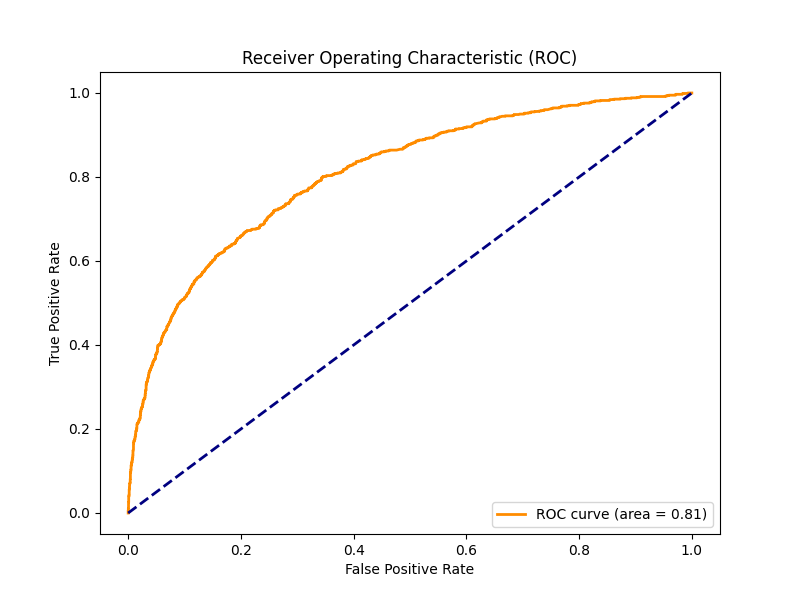

In [11]:
path_pesos = "pesos/unimodales_ajuste/pesos_baseline_unimodal_texto_roberta64_ventana64_pdim512_hmlp128_do0.3_lr5e-05.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--split test "
        f"--text roberta64 "
        f"--proj_dim 512 "
        f"--hidden_mlp 128 "
        f"--dropout 0.3 "
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_TEXTO_roberta64_test.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_TEXTO_roberta64_test.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

**Tabla comparativa con los resultados en test de los 3 *baselines* unimodales ajustados**:

En la tabla se reflejan las 4 métricas principales (**F1-Score Macro**, **Balanced Accuracy**, **ROC-AUC**, **Recall (estrés)**) para cada uno de los modelos:

* **Estos resultados se compararán con las arquitectures multimodales finalmente ajustadas, para cuantificar la ganancia o pérdida de rendimiento en la fusión.**

In [ ]:
def extraer_metricas_txt(ruta_txt):
    """
    Abre el reporte .txt y extrae el F1-Score Macro, Balanced Accuracy, el ROC-AUC y el Recall de la clase 'Estrés'.
    """
    f1_macro = 0.0
    auc = 0.0
    ba = 0.0
    recall_estres = 0.0
    
    if not os.path.exists(ruta_txt):
        print(f"No se encuentra el archivo {ruta_txt}")
        return f1_macro, auc, recall_estres
        
    with open(ruta_txt, 'r', encoding='utf-8') as f:
        lineas = f.readlines()
        
    for linea in lineas:
        if "Balanced Accuracy" in linea:
            ba = float(linea.split(":")[1].strip())
        if "ROC-AUC:" in linea:
            auc = float(linea.split(":")[1].strip())
        elif "macro avg" in linea:
            # Ejemplo de línea que puede estar en el reporte: "macro avg    0.80      0.79      0.79       200"
            partes = linea.split()
            f1_macro = float(partes[4]) # El F1-Score está en la 5ª columna
        elif linea.strip().startswith("Estrés"):
            # Ejemplo de línea típica: "   Estrés       0.85      0.82      0.83       100"
            # partes[0]='Estrés', partes[1]=Precision, partes[2]=Recall
            partes = linea.split()
            recall_estres = float(partes[2])
            
    return f1_macro, ba, auc, recall_estres

In [15]:
# Definimos los 3 modelos base, su modalidad, ventana y la ruta de su txt:
rutas_baselines = [
    # VÍDEO 
    {'Modelo': 'ResNet', 'Modalidad': 'Vídeo', 'Ventana': '32 frames', 
     'Ruta': 'resultados/unimodales/test/reporte_final_baseline_unimodal_VIDEO_resnet_test.txt'},
    
    # AUDIO 
    {'Modelo': 'Wav2Vec 2.0', 'Modalidad': 'Audio', 'Ventana': '7 seg', 
     'Ruta': 'resultados/unimodales/test/reporte_final_baseline_unimodal_AUDIO_wav2vec_test.txt'},
    
    # TEXTO 
    {'Modelo': 'RoBERTa', 'Modalidad': 'Texto', 'Ventana': '64 tokens', 
     'Ruta': 'resultados/unimodales/test/reporte_final_baseline_unimodal_TEXTO_roberta64_test.txt'}
]

datos_baselines = []
for item in rutas_baselines:
    f1, ba, auc, recall = extraer_metricas_txt(item['Ruta'])
    datos_baselines.append({
        'Modalidad': item['Modalidad'],
        'Modelo': item['Modelo'],
        'Ventana': item['Ventana'],
        'F1_Macro': f1,
        'Balanced_Accuracy': ba,
        'AUC': auc,
        'Recall_Estres': recall
    })

# Creamos el DataFrame y lo ordenamos por Modalidad y luego por F1:
df_baselines = pd.DataFrame(datos_baselines).sort_values(by='F1_Macro', ascending=False)

# Lo guardamos como CSV:
df_baselines.to_csv("tabla_baselines_unimodales_test.csv", index=False)

# Mostramos en pantalla
print("TABLA: BASELINES UNIMODALES AJUSTADOS EN TEST")
display(df_baselines.style.background_gradient(subset=['F1_Macro', 'Balanced_Accuracy', 'AUC', 'Recall_Estres'], cmap='Blues').format(precision=4))

TABLA: BASELINES UNIMODALES AJUSTADOS EN TEST


,Modalidad,Modelo,Ventana,F1_Macro,Balanced_Accuracy,AUC,Recall_Estres
2,Texto,RoBERTa,64 tokens,0.7137,0.7279,0.8078,0.6182
0,Vídeo,ResNet,32 frames,0.5847,0.6138,0.6553,0.5366
1,Audio,Wav2Vec 2.0,7 seg,0.5330,0.5391,0.5797,0.1433


De los 3 baselines unimodales obtenidos, es el de texto el que mayor rendimiento consigue para la tarea, mientras que Wav2Vec 2.0 es el que obtiene peor rendimiento. Se mantiene, por tanto, el mismo patrón observado en la partición de validación. 

---
Estos resultados en **test** se tendrán en cuenta para el posterior análisis comparativo con la mejor arquitectura multimodal entrenada sobre el corpus global y ajustada con los mismos hiperparámetros (llevando a cabo estos mismos Grid Search secuenciales), comprobando si el modelo se ve beneficiado realmente de la fusión multimodal. 

---